In [2]:
# ============================================================
# Results Notebook — Cohort and ECG Segment Overview
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Set paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent   # change this if your CSVs are in another folder

OUTPUT_DIR = PROJECT_ROOT / "outputs"

data_integrity_path = OUTPUT_DIR / "data_audit" / "data_integrity_summary.csv"
segment_counts_path = OUTPUT_DIR / "data_audit" / "segment_counts_by_patient_condition.csv"
informative_feature_summary_path =  OUTPUT_DIR / "feature_definition" / "informative_feature_summary.csv"
cohort_description_path = OUTPUT_DIR / "clinical_metadata" / "cohort_description_table.csv"
qc_exclusion_counts_path = OUTPUT_DIR / "segment_qc" / "qc_exclusion_counts.csv"

OUTPUT_DIR = Path("results_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Load files
# ------------------------------------------------------------

data_integrity = pd.read_csv(data_integrity_path)
segment_counts = pd.read_csv(segment_counts_path)
informative_summary = pd.read_csv(informative_feature_summary_path)
cohort_description = pd.read_csv(cohort_description_path)
qc_exclusion_counts = pd.read_csv(qc_exclusion_counts_path)

# Helpful display
print("Loaded files:")
print("data_integrity:", data_integrity.shape)
print("segment_counts:", segment_counts.shape)
print("informative_summary:", informative_summary.shape)
print("cohort_description:", cohort_description.shape)
print("qc_exclusion_counts:", qc_exclusion_counts.shape)

Loaded files:
data_integrity: (11, 2)
segment_counts: (63, 5)
informative_summary: (4, 2)
cohort_description: (20, 2)
qc_exclusion_counts: (11, 3)


In [4]:
# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def get_metric(df, key, metric_col="metric", value_col="value"):
    """Return a scalar metric value from a two-column metric/value table."""
    match = df.loc[df[metric_col] == key, value_col]
    if match.empty:
        return np.nan
    return match.iloc[0]


def get_characteristic(df, key, characteristic_col="characteristic", value_col="value"):
    """Return a scalar value from a characteristic/value table."""
    match = df.loc[df[characteristic_col] == key, value_col]
    if match.empty:
        return np.nan
    return match.iloc[0]


def fmt_int(x):
    """Format integer-like values with commas."""
    if pd.isna(x):
        return ""
    return f"{int(float(x)):,}"

In [5]:
# ------------------------------------------------------------
# 4. Table I — Cohort, ECG Segment, and Analysis Design Summary
# ------------------------------------------------------------

# Total Pre-HI and During-HI segments
condition_segment_counts = (
    segment_counts
    .groupby("Condition_std", as_index=False)["n_segments"]
    .sum()
)

prehi_segments = int(
    condition_segment_counts.loc[
        condition_segment_counts["Condition_std"] == "PreHI", "n_segments"
    ].sum()
)

hi_segments = int(
    condition_segment_counts.loc[
        condition_segment_counts["Condition_std"] == "HI", "n_segments"
    ].sum()
)

# Number of patients with both conditions
patient_condition_counts = (
    segment_counts
    .groupby(["Patient_id", "Condition_std"])["n_segments"]
    .sum()
    .unstack(fill_value=0)
)

patients_with_both = int(
    ((patient_condition_counts.get("PreHI", 0) > 0) &
     (patient_condition_counts.get("HI", 0) > 0)).sum()
)

# Segment range per patient
patient_segment_totals = (
    segment_counts
    .groupby("Patient_id", as_index=False)["n_segments"]
    .sum()
)

segment_range = (
    f"{patient_segment_totals['n_segments'].min()}–"
    f"{patient_segment_totals['n_segments'].max()}"
)

# Episode count per patient, excluding PreHI label
hi_episode_counts = (
    segment_counts[segment_counts["Condition_std"] == "HI"]
    .groupby("Patient_id")["Episode_Label"]
    .nunique()
)

episode_range = f"{hi_episode_counts.min()}–{hi_episode_counts.max()}"

n_patients_more_than_one_hi_episode = int((hi_episode_counts > 1).sum())

table1 = pd.DataFrame({
    "Characteristic": [
        "Number of patients",
        "Total 2-min Lead-II ECG segments",
        "Pre-HI segments",
        "During-HI segments",
        "Patients with both Pre-HI and During-HI segments",
        "Segment count per patient, range",
        "HI episode labels per patient, range",
        "Patients with >1 HI episode label",
        "Full ECG-derived feature set",
        "Informative ECG-derived features analyzed",
        "Excluded non-informative features",
        "Minimum paired patients required per feature",
        "Primary statistical unit",
        "Primary paired summary",
        "Segment-level primary inference"
    ],
    "Value": [
        fmt_int(get_metric(data_integrity, "n_unique_patients")),
        fmt_int(get_metric(data_integrity, "n_rows")),
        fmt_int(prehi_segments),
        fmt_int(hi_segments),
        fmt_int(patients_with_both),
        segment_range,
        episode_range,
        fmt_int(n_patients_more_than_one_hi_episode),
        fmt_int(get_metric(informative_summary, "n_full_ecg_features")),
        fmt_int(get_metric(informative_summary, "n_informative_features")),
        fmt_int(get_metric(informative_summary, "n_excluded_features")),
        fmt_int(get_metric(informative_summary, "min_paired_patients_required")),
        "Patient",
        "One Pre-HI median and one During-HI median per patient-feature pair",
        "No"
    ]
})

table1

,Characteristic,Value
0,Number of patients,20
1,Total 2-min Lead-II ECG segments,"1,260"
2,Pre-HI segments,593
3,During-HI segments,667
4,Patients with both Pre-HI and During-HI segments,20
5,"Segment count per patient, range",45–89
6,"HI episode labels per patient, range",1–6
7,Patients with >1 HI episode label,12
8,Full ECG-derived feature set,56
9,Informative ECG-derived features analyzed,52


In [6]:
# Save Table I as CSV and LaTeX
table1.to_csv(TABLE_DIR / "table1_cohort_segment_analysis_summary.csv", index=False)

latex_table1 = table1.to_latex(
    index=False,
    escape=False,
    column_format="p{0.55\\linewidth}p{0.35\\linewidth}",
    caption="Cohort, ECG Segment, and Analysis Design Summary.",
    label="tab:cohort_segment_analysis_summary"
)

with open(TABLE_DIR / "table1_cohort_segment_analysis_summary.tex", "w") as f:
    f.write(latex_table1)

print(latex_table1)

\begin{table}
\caption{Cohort, ECG Segment, and Analysis Design Summary.}
\label{tab:cohort_segment_analysis_summary}
\begin{tabular}{p{0.55\linewidth}p{0.35\linewidth}}
\toprule
Characteristic & Value \\
\midrule
Number of patients & 20 \\
Total 2-min Lead-II ECG segments & 1,260 \\
Pre-HI segments & 593 \\
During-HI segments & 667 \\
Patients with both Pre-HI and During-HI segments & 20 \\
Segment count per patient, range & 45–89 \\
HI episode labels per patient, range & 1–6 \\
Patients with >1 HI episode label & 12 \\
Full ECG-derived feature set & 56 \\
Informative ECG-derived features analyzed & 52 \\
Excluded non-informative features & 4 \\
Minimum paired patients required per feature & 10 \\
Primary statistical unit & Patient \\
Primary paired summary & One Pre-HI median and one During-HI median per patient-feature pair \\
Segment-level primary inference & No \\
\bottomrule
\end{tabular}
\end{table}



In [7]:
# ------------------------------------------------------------
# 5. Table II — Clinical/Rhythm Context Summary
# ------------------------------------------------------------

clinical_rows_to_show = [
    "paced_or_icd",
    "BBB",
    "continuous_AF",
    "intermittent_or_new_AF",
    "any_af",
    "paced_or_bbb",
    "major_HRV_outlier",
    "antiarrhythmic_exposure",
    "mechanical_support",
    "atypical_HI",
    "clean_sinus_candidate",
    "exclude_from_HRV_valid_subgroup",
    "hrv_invalid_flag",
    "known_artifact_patient_flag",
    "high_confound",
    "moderate_or_high_confound",
    "confound_count_median_IQR"
]

clinical_label_map = {
    "paced_or_icd": "Paced rhythm or ICD",
    "BBB": "Bundle branch block",
    "continuous_AF": "Continuous atrial fibrillation",
    "intermittent_or_new_AF": "Intermittent or new atrial fibrillation",
    "any_af": "Any atrial fibrillation",
    "paced_or_bbb": "Pacing or bundle branch block",
    "major_HRV_outlier": "Major HRV/R-peak outlier",
    "antiarrhythmic_exposure": "Antiarrhythmic exposure",
    "mechanical_support": "Mechanical support",
    "atypical_HI": "Atypical HI context",
    "clean_sinus_candidate": "Clean sinus-rhythm candidate",
    "exclude_from_HRV_valid_subgroup": "Excluded from HRV-valid subgroup",
    "hrv_invalid_flag": "HRV-invalid flag",
    "known_artifact_patient_flag": "Known signal/artifact caution",
    "high_confound": "High clinical confound burden",
    "moderate_or_high_confound": "Moderate/high clinical confound burden",
    "confound_count_median_IQR": "Clinical confound count, median [IQR]"
}

table2_rows = []

for key in clinical_rows_to_show:
    value = get_characteristic(cohort_description, key)
    if pd.notna(value):
        table2_rows.append({
            "Clinical/Rhythm Characteristic": clinical_label_map.get(key, key),
            "Value": value
        })

table2 = pd.DataFrame(table2_rows)

table2

,Clinical/Rhythm Characteristic,Value
0,Paced rhythm or ICD,5/20 (25.0%)
1,Bundle branch block,4/20 (20.0%)
2,Continuous atrial fibrillation,3/20 (15.0%)
3,Intermittent or new atrial fibrillation,3/20 (15.0%)
4,Any atrial fibrillation,6/20 (30.0%)
5,Pacing or bundle branch block,6/20 (30.0%)
6,Major HRV/R-peak outlier,1/20 (5.0%)
7,Antiarrhythmic exposure,5/20 (25.0%)
8,Mechanical support,3/20 (15.0%)
9,Atypical HI context,3/20 (15.0%)


In [8]:
# Save Table II as CSV and LaTeX
table2.to_csv(TABLE_DIR / "table2_clinical_rhythm_context_summary.csv", index=False)

latex_table2 = table2.to_latex(
    index=False,
    escape=False,
    column_format="p{0.58\\linewidth}p{0.25\\linewidth}",
    caption="Clinical and Rhythm Context of the 20-Patient Cohort.",
    label="tab:clinical_rhythm_context"
)

with open(TABLE_DIR / "table2_clinical_rhythm_context_summary.tex", "w") as f:
    f.write(latex_table2)

print(latex_table2)

\begin{table}
\caption{Clinical and Rhythm Context of the 20-Patient Cohort.}
\label{tab:clinical_rhythm_context}
\begin{tabular}{p{0.58\linewidth}p{0.25\linewidth}}
\toprule
Clinical/Rhythm Characteristic & Value \\
\midrule
Paced rhythm or ICD & 5/20 (25.0%) \\
Bundle branch block & 4/20 (20.0%) \\
Continuous atrial fibrillation & 3/20 (15.0%) \\
Intermittent or new atrial fibrillation & 3/20 (15.0%) \\
Any atrial fibrillation & 6/20 (30.0%) \\
Pacing or bundle branch block & 6/20 (30.0%) \\
Major HRV/R-peak outlier & 1/20 (5.0%) \\
Antiarrhythmic exposure & 5/20 (25.0%) \\
Mechanical support & 3/20 (15.0%) \\
Atypical HI context & 3/20 (15.0%) \\
Clean sinus-rhythm candidate & 4/20 (20.0%) \\
Excluded from HRV-valid subgroup & 8/20 (40.0%) \\
HRV-invalid flag & 8/20 (40.0%) \\
Known signal/artifact caution & 5/20 (25.0%) \\
High clinical confound burden & 3/20 (15.0%) \\
Moderate/high clinical confound burden & 6/20 (30.0%) \\
Clinical confound count, median [IQR] & 1.0 [1.0, 2.0] \

In [9]:
# ------------------------------------------------------------
# 6. Table III — Segment-QC Overview
# ------------------------------------------------------------

qc_label_map = {
    "qc_clear_segment_flag": "QC-clear segments",
    "clear_segment_qc_exclusion_flag": "Segments with clear QC exclusion flag",
    "near_zero_signal_flag": "Near-zero signal",
    "low_variability_signal_flag": "Low-variability signal",
    "qrs_std_zero_flag": "QRS standard deviation equal/near zero",
    "known_artifact_segment_flag": "Known artifact segment",
    "extreme_value_review_flag": "Extreme-value review flag",
    "extreme_kurtosis_review_flag": "Extreme kurtosis review flag",
    "known_patient_qc_caution_flag": "Known patient-level QC caution",
    "signal_review_flag": "Signal review flag",
    "missing_any_informative_feature_flag": "Missing any informative feature"
}

qc_table = qc_exclusion_counts.copy()
qc_table["QC category"] = qc_table["qc_flag"].map(qc_label_map).fillna(qc_table["qc_flag"])
qc_table["Segments, n"] = qc_table["n_segments_flagged"].astype(int)
qc_table["Segments, %"] = qc_table["percent_segments_flagged"].map(lambda x: f"{x:.1f}")

table3 = qc_table[["QC category", "Segments, n", "Segments, %"]].copy()

table3

,QC category,"Segments, n","Segments, %"
0,QC-clear segments,1153,91.5
1,Known patient-level QC caution,302,24.0
2,Extreme-value review flag,270,21.4
3,Segments with clear QC exclusion flag,107,8.5
4,Low-variability signal,101,8.0
5,Signal review flag,58,4.6
6,Extreme kurtosis review flag,8,0.6
7,Missing any informative feature,5,0.4
8,QRS standard deviation equal/near zero,5,0.4
9,Known artifact segment,2,0.2


In [10]:
# Save Table III as CSV and LaTeX
table3.to_csv(TABLE_DIR / "table3_segment_qc_overview.csv", index=False)

latex_table3 = table3.to_latex(
    index=False,
    escape=False,
    column_format="p{0.58\\linewidth}rr",
    caption="Segment-Level Quality-Control Overview. QC flags were used for review and sensitivity analysis, not for primary full-cohort exclusion.",
    label="tab:segment_qc_overview"
)

with open(TABLE_DIR / "table3_segment_qc_overview.tex", "w") as f:
    f.write(latex_table3)

print(latex_table3)

\begin{table}
\caption{Segment-Level Quality-Control Overview. QC flags were used for review and sensitivity analysis, not for primary full-cohort exclusion.}
\label{tab:segment_qc_overview}
\begin{tabular}{p{0.58\linewidth}rr}
\toprule
QC category & Segments, n & Segments, % \\
\midrule
QC-clear segments & 1153 & 91.5 \\
Known patient-level QC caution & 302 & 24.0 \\
Extreme-value review flag & 270 & 21.4 \\
Segments with clear QC exclusion flag & 107 & 8.5 \\
Low-variability signal & 101 & 8.0 \\
Signal review flag & 58 & 4.6 \\
Extreme kurtosis review flag & 8 & 0.6 \\
Missing any informative feature & 5 & 0.4 \\
QRS standard deviation equal/near zero & 5 & 0.4 \\
Known artifact segment & 2 & 0.2 \\
Near-zero signal & 1 & 0.1 \\
\bottomrule
\end{tabular}
\end{table}



In [11]:
# ------------------------------------------------------------
# 7. Figure 1 — Patient-wise ECG segment availability
# ------------------------------------------------------------

# Collapse across episode labels to total Pre-HI and HI segments per patient
segment_by_patient_condition = (
    segment_counts
    .groupby(["Patient_id", "Condition_std"], as_index=False)["n_segments"]
    .sum()
)

segment_wide = (
    segment_by_patient_condition
    .pivot(index="Patient_id", columns="Condition_std", values="n_segments")
    .fillna(0)
)

# Ensure consistent columns
for col in ["PreHI", "HI"]:
    if col not in segment_wide.columns:
        segment_wide[col] = 0

segment_wide = segment_wide[["PreHI", "HI"]].copy()

# Sort by patient ID numerically when possible
segment_wide = segment_wide.reset_index()
segment_wide["Patient_id_numeric"] = pd.to_numeric(segment_wide["Patient_id"], errors="coerce")
segment_wide = segment_wide.sort_values(["Patient_id_numeric", "Patient_id"])
segment_wide = segment_wide.drop(columns=["Patient_id_numeric"])

segment_wide

Condition_std,Patient_id,PreHI,HI
0,491,30,30
1,638,24,36
2,906,30,28
3,1049,30,31
4,1855,29,32
5,8452,30,59
6,10013,30,30
7,26398,30,30
8,26502,30,58
9,27245,30,30


In [14]:
# Plot
# ------------------------------------------------------------
# 2. Shared IEEE-style figure settings
# Reuse this block for later manuscript figures.
# ------------------------------------------------------------

IEEE_STYLE = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

# Okabe–Ito colorblind-safe palette
COLOR_PREHI = "#0072B2"   # blue
COLOR_HI = "#E69F00"      # orange

plt.rcParams.update(IEEE_STYLE)

# IEEE Access double-column width is approximately 7.16 inches.
FIG_WIDTH_IN = 7.16
FIG_HEIGHT_IN = 3.2

# ------------------------------------------------------------
# 4. Figure function
# ------------------------------------------------------------

def plot_segment_availability(segment_wide, save_dir, filename_stem):
    """
    Plot patient-wise ECG segment availability as a stacked bar chart.

    Parameters
    ----------
    segment_wide : pandas.DataFrame
        DataFrame with columns ["Patient_id", "PreHI", "HI"].
    save_dir : pathlib.Path
        Output directory for figure files.
    filename_stem : str
        Base filename without extension.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Generated figure object.
    """

    required_cols = {"Patient_id", "PreHI", "HI"}
    missing_cols = required_cols - set(segment_wide.columns)

    if missing_cols:
        raise ValueError(f"segment_wide is missing columns: {missing_cols}")

    x = np.arange(len(segment_wide))
    bar_width = 0.72

    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
        constrained_layout=True
    )

    ax.bar(
        x,
        segment_wide["PreHI"],
        width=bar_width,
        label="Pre-HI",
        color=COLOR_PREHI,
        edgecolor="white",
        linewidth=0.3,
    )

    ax.bar(
        x,
        segment_wide["HI"],
        width=bar_width,
        bottom=segment_wide["PreHI"],
        label="During-HI",
        color=COLOR_HI,
        edgecolor="white",
        linewidth=0.3,
    )

    ax.set_xlabel("Patient ID")
    ax.set_ylabel("Number of 2-minute ECG segments")

    ax.set_xticks(x)
    ax.set_xticklabels(
        segment_wide["Patient_id"].astype(str),
        rotation=45,
        ha="right",
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.6,
        color="0.6",
        zorder=0
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
        handlelength=1.2,
        columnspacing=1.2,
    )

    save_dir.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        save_dir / f"{filename_stem}.pdf",
        bbox_inches="tight"
    )

    fig.savefig(
        save_dir / f"{filename_stem}.png",
        dpi=600,
        bbox_inches="tight"
    )

    return fig


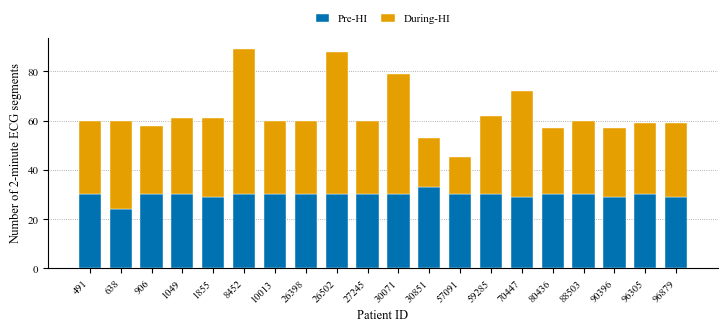

In [15]:
fig = plot_segment_availability(
    segment_wide=segment_wide,
    save_dir=FIGURE_DIR,
    filename_stem="figure1_patient_wise_segment_availability"
)

plt.show()

In [13]:
# ------------------------------------------------------------
# 8. Suggested caption text
# ------------------------------------------------------------

figure1_caption = (
    "Patient-wise availability of non-overlapping 2-minute Lead-II ECG segments "
    "in the Pre-HI and During-HI conditions. Segment availability varied across "
    "patients because the number and duration of clinically labelled HI episodes "
    "differed across the cohort. The primary analysis therefore collapsed "
    "segment-level feature values into paired patient-level medians before "
    "inferential testing."
)

print(figure1_caption)

Patient-wise availability of non-overlapping 2-minute Lead-II ECG segments in the Pre-HI and During-HI conditions. Segment availability varied across patients because the number and duration of clinically labelled HI episodes differed across the cohort. The primary analysis therefore collapsed segment-level feature values into paired patient-level medians before inferential testing.
